c:\Users\Anand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


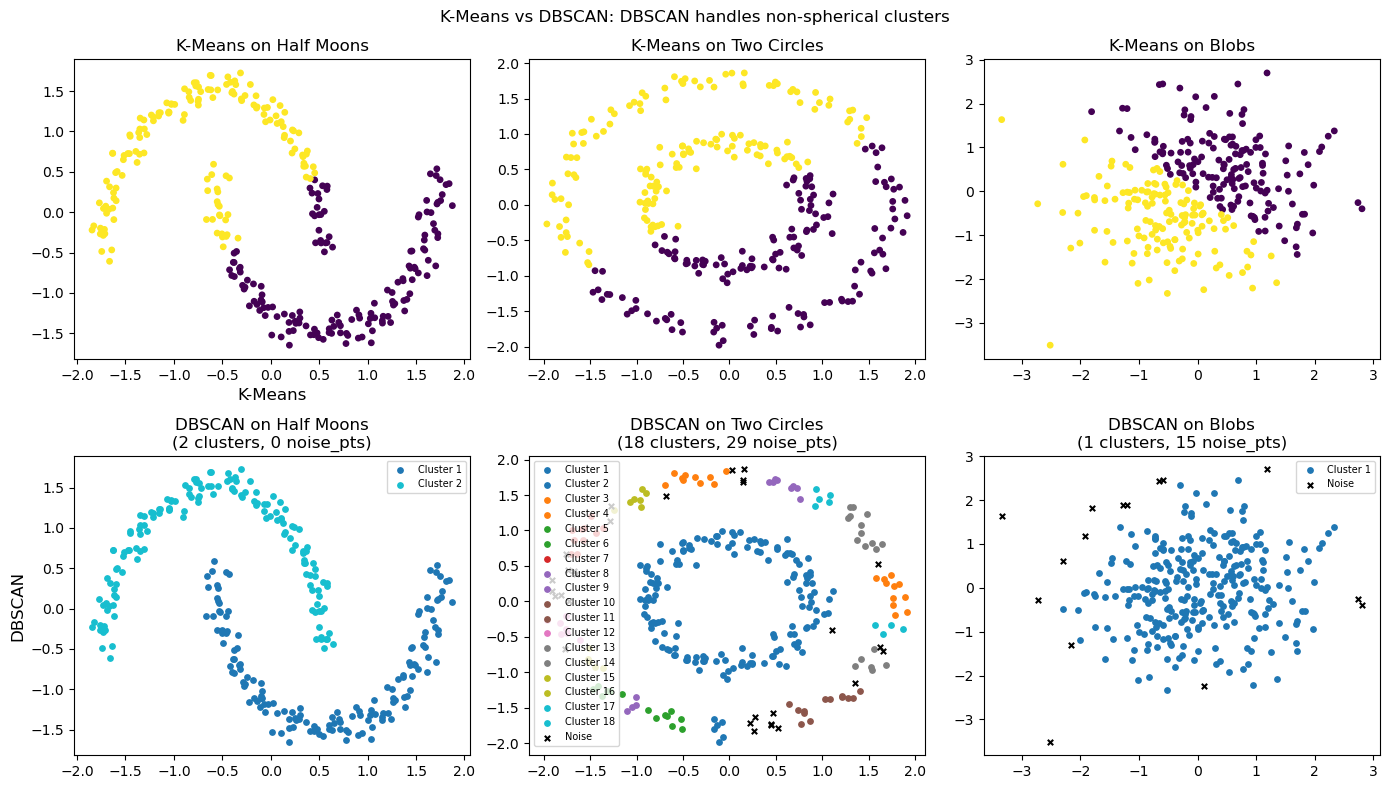


 DBSCAN Results (half_moon_datasets): 
 Core Points: 299
  Border points: 1
  Noise points:  0
  Clusters found:2


In [1]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons, make_circles
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

datasets = [
    ('Half Moons',  make_moons(n_samples=300,   noise=0.05, random_state=42)),
    ('Two Circles', make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)),
    ('Blobs',       (np.random.randn(300, 2) * np.array([2, 0.5]), np.zeros(300)))
]

dbscan_params = [
    {'eps': 0.3, 'min_samples': 5},
    {'eps': 0.2, 'min_samples': 5},
    {'eps': 0.5, 'min_samples': 5}
]

for col, ((name, (X, _)), params) in enumerate(zip(datasets, dbscan_params)):
  X = StandardScaler().fit_transform(X)

  km = KMeans(n_clusters=2, random_state=42, n_init=10)
  km_labels = km.fit_predict(X)
  axes[0, col].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='viridis', s=15)
  axes[0, col].set_title(f'K-Means on {name}')

  db = DBSCAN(**params)
  db_labels = db.fit_predict(X)
  n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
  n_noise = (db_labels == -1).sum()

  colors = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))
  for label in set(db_labels):
    mask = db_labels == label
    color = 'black' if label == -1 else colors[label % len(colors)]
    marker = 'x' if label == -1 else 'o' # Changed '0' to 'o'
    lbl = 'Noise' if label == -1 else f'Cluster {label+1}'
    axes[1, col].scatter(X[mask, 0], X[mask, 1], c=[color], s=15, marker=marker, label=lbl)

  axes[1, col].set_title(f'DBSCAN on {name}\n({n_clusters} clusters, {n_noise} noise_pts)')
  axes[1, col].legend(fontsize=7)

axes[0, 0].set_xlabel('K-Means', fontsize=12)
axes[1, 0].set_ylabel('DBSCAN', fontsize=12)
plt.suptitle('K-Means vs DBSCAN: DBSCAN handles non-spherical clusters', fontsize=12)
plt.tight_layout()
plt.show()

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
X = StandardScaler().fit_transform(X)
db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(X)

core_mask = np.zeros_like(labels, dtype=bool)
core_mask[db.core_sample_indices_] = True

print(f"\n DBSCAN Results (half_moon_datasets): ")
print(f" Core Points: {core_mask.sum()}")
print(f"  Border points: {((labels != -1) & ~core_mask).sum()}")
print(f"  Noise points:  {(labels == -1).sum()}")
print(f"  Clusters found:{len(set(labels)) - (1 if -1 in labels else 0)}")